In [1]:
import sys
sys.path.append("/Users/avelezxerenity/Documents/GitHub/pysdk")
import os
from inflation_query.Inflation_query import implied_inflation_calc
from src.xerenity.xty import Xerenity
from utilities.date_functions import add_months
import pandas as pd
import QuantLib as ql
from datetime import datetime
xty = Xerenity(
    username=os.getenv('XTY_USER'),
    password=os.getenv('XTY_PWD'),
)

2023-11-02 19:28:08,815:INFO - HTTP Request: POST https://tvpehjbqxpiswkqszwwv.supabase.co/auth/v1/token?grant_type=password "HTTP/1.1 200 OK"
2023-11-02 19:28:09,581:INFO - HTTP Request: POST https://tvpehjbqxpiswkqszwwv.supabase.co/auth/v1/token?grant_type=password "HTTP/1.1 200 OK"


In [2]:
%%capture
cpi=implied_inflation_calc()
indice=cpi['total_cpi']
indice.index = pd.to_datetime(indice.index).date
uvr=xty.BanRep().get_econ_data_last_n(id_serie=8,n=10).data
uvr=pd.DataFrame(uvr)
uvr['fecha'] = pd.to_datetime(uvr['fecha'])
uvr.drop('id_serie', axis=1, inplace=True)
uvr.set_index('fecha', inplace=True)
uvr.index = pd.to_datetime(uvr.index).date
uvr


2023-11-02 19:28:10,888:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/banrep_serie_value?select=%2A&id_serie=eq.1&order=fecha.desc&limit=1 "HTTP/1.1 200 OK"
2023-11-02 19:28:11,096:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:28:11,386:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes_32?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:28:11,584:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes_31?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:28:11,810:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes_25?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:28:12,036:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes_26?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:28:12,190:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/tes_27?select=%2A "HTTP/1.1 200 OK"
2023-11-02 19:

In [3]:
init_date = max(uvr.index)
for m in range(0, 121):
    current_date = add_months(init_date,m).date()
    next_date=add_months(current_date,1).date()
    try:
        current_index_value=indice.loc[current_date]['Total']
        next_index_value=indice.loc[next_date]['Total']
        valor_uvr=uvr.loc[current_date]['valor']
        uvr.loc[next_date]=valor_uvr*next_index_value/current_index_value
    except:
        print("Existio un error solo se pudo calcular hasta el año")
        print(current_date)


Existio un error solo se pudo calcular hasta el año
2033-10-15
Existio un error solo se pudo calcular hasta el año
2033-11-15


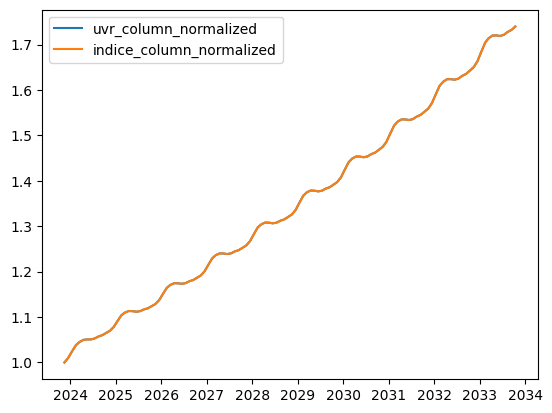

In [11]:
# Assuming merged_df is the merged DataFrame from the previous code

# Get the values on November 15, 2023
uvr_value = merged_df.loc[init_date, 'valor']
indice_value = merged_df.loc[init_date, 'Total']

# Normalize the columns
merged_df['uvr_column_normalized'] = merged_df['valor'] / uvr_value
merged_df['indice_column_normalized'] = merged_df['Total'] / indice_value

# Plot the normalized columns
plt.plot(merged_df.index, merged_df['uvr_column_normalized'], label='uvr_column_normalized')
plt.plot(merged_df.index, merged_df['indice_column_normalized'], label='indice_column_normalized')
plt.legend()
plt.show()



In [ ]:

today = datetime.now().date()
index_prev=1
for index, row in indice.iterrows():
    index_actual=row['Total']
    if index > today:
        # Print the entire row for timestamps greater than today
        #print(row['Total'])
        uvr_actual=index_actual/index_prev
        #print(add_months(index,-1))
        # uvr.loc[index]=
        index_prev=row['Total']
    try:
        uvr_prev=uvr.loc[index]['valor']
    except:
        pass



    






In [ ]:
uvr